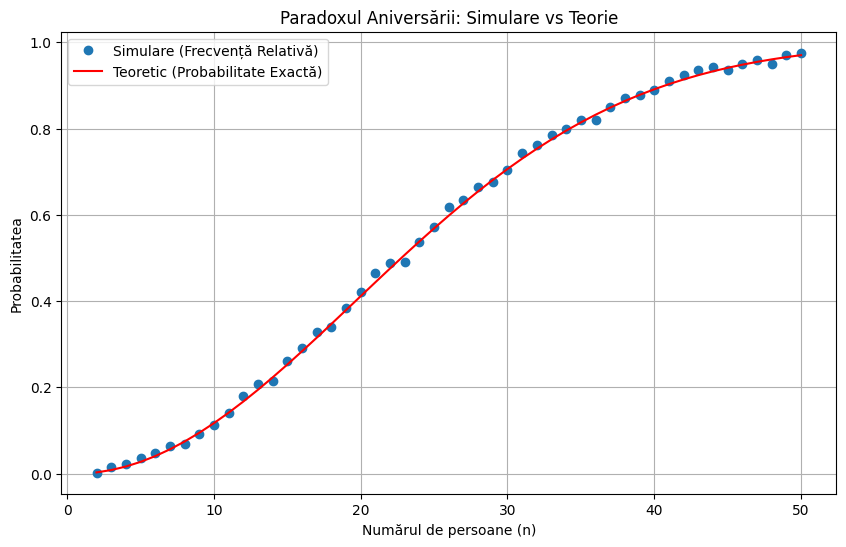

In [1]:
import random
import matplotlib.pyplot as plt

# n - numarul de persoane
# nr_sim - numarul de simulari

def prob_aniversare_sim(n, num_sim=1000):
    count = 0
    for _ in range(num_sim):
        zile = [random.randint(1, 365) for _ in range(n)]
        if len(set(zile)) < n:
            count += 1

    return count / num_sim

def prob_aniversare_teoretic(n):
    p_distinct = 1.0
    for i in range(n):
        p_distinct *= (365 - i) / 365
    return 1 - p_distinct

ns = range(2, 51)
y_sim = [prob_aniversare_sim(n) for n in ns]
y_teo = [prob_aniversare_teoretic(n) for n in ns]

plt.figure(figsize=(10, 6))
# cu 'o' desenezi cercuri
plt.plot(ns, y_sim, 'o', label='Simulare (Frecvență Relativă)')
plt.plot(ns, y_teo, 'r-', label='Teoretic (Probabilitate Exactă)')
plt.xlabel('Numărul de persoane (n)')
plt.ylabel('Probabilitatea')
plt.title('Paradoxul Aniversării: Simulare vs Teorie')
plt.legend()
plt.grid(True)
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


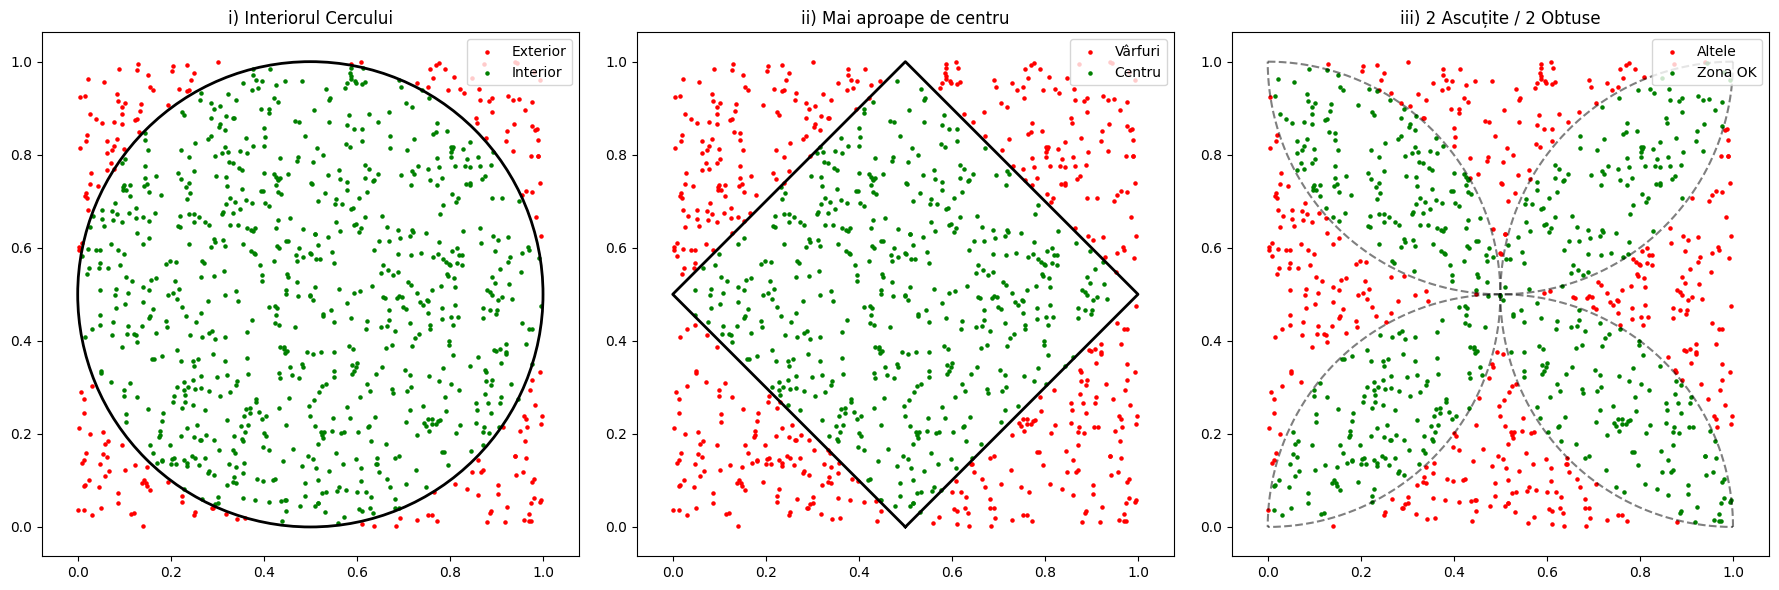

In [3]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np # Folosim numpy doar pentru a desena cercurile mai ușor

# 1. Configurare
N = 1000  # Număr puncte (mai mic pentru a se vedea clar pe grafic)
plt.figure(figsize=(18, 6)) # O figură mare cu 3 sub-grafice

# Liste pentru a stoca punctele pentru fiecare caz (True/False)
# Caz i
pts_i_ok_x, pts_i_ok_y = [], []
pts_i_not_x, pts_i_not_y = [], []

# Caz ii
pts_ii_ok_x, pts_ii_ok_y = [], []
pts_ii_not_x, pts_ii_not_y = [], []

# Caz iii
pts_iii_ok_x, pts_iii_ok_y = [], []
pts_iii_not_x, pts_iii_not_y = [], []

varfuri = [(0,0), (1,0), (0,1), (1,1)]

# 2. Simulare și Clasificare
for _ in range(N):
    x = random.random()
    y = random.random()

    # --- Caz i (Cerc) ---
    if (x - 0.5)**2 + (y - 0.5)**2 < 0.25:
        pts_i_ok_x.append(x); pts_i_ok_y.append(y)
    else:
        pts_i_not_x.append(x); pts_i_not_y.append(y)

    # --- Caz ii (Centru) ---
    d_c = math.sqrt((x-0.5)**2 + (y-0.5)**2)
    d_v_min = min([math.sqrt((x-vx)**2 + (y-vy)**2) for vx, vy in varfuri])

    if d_c < d_v_min:
        pts_ii_ok_x.append(x); pts_ii_ok_y.append(y)
    else:
        pts_ii_not_x.append(x); pts_ii_not_y.append(y)

    # --- Caz iii (Triunghiuri/Petale) ---
    o1 = (x - 0.5)**2 + y**2 < 0.25
    o2 = (x - 0.5)**2 + (y - 1)**2 < 0.25
    o3 = x**2 + (y - 0.5)**2 < 0.25
    o4 = (x - 1)**2 + (y - 0.5)**2 < 0.25

    if sum([o1, o2, o3, o4]) == 2:
        pts_iii_ok_x.append(x); pts_iii_ok_y.append(y)
    else:
        pts_iii_not_x.append(x); pts_iii_not_y.append(y)

# 3. Desenare Grafică

# --- Grafic 1: Interiorul Cercului ---
plt.subplot(1, 3, 1)
plt.title("i) Interiorul Cercului")
plt.axis('equal'); plt.xlim(0, 1); plt.ylim(0, 1)
# Desenăm punctele
plt.scatter(pts_i_not_x, pts_i_not_y, color='red', s=5, label='Exterior')
plt.scatter(pts_i_ok_x, pts_i_ok_y, color='green', s=5, label='Interior')
# Desenăm conturul cercului
circle = plt.Circle((0.5, 0.5), 0.5, color='black', fill=False, linewidth=2)
plt.gca().add_patch(circle)
plt.legend(loc='upper right')

# --- Grafic 2: Mai aproape de centru ---
plt.subplot(1, 3, 2)
plt.title("ii) Mai aproape de centru")
plt.axis('equal'); plt.xlim(0, 1); plt.ylim(0, 1)
# Desenăm punctele
plt.scatter(pts_ii_not_x, pts_ii_not_y, color='red', s=5, label='Vârfuri')
plt.scatter(pts_ii_ok_x, pts_ii_ok_y, color='green', s=5, label='Centru')
# Desenăm granița (Pătratul rotit care delimitează zona)
plt.plot([0.5, 1, 0.5, 0, 0.5], [0, 0.5, 1, 0.5, 0], 'k-', linewidth=2)
plt.legend(loc='upper right')

# --- Grafic 3: Triunghiuri (Petale) ---
plt.subplot(1, 3, 3)
plt.title("iii) 2 Ascuțite / 2 Obtuse")
plt.axis('equal'); plt.xlim(0, 1); plt.ylim(0, 1)
# Desenăm punctele
plt.scatter(pts_iii_not_x, pts_iii_not_y, color='red', s=5, label='Altele')
plt.scatter(pts_iii_ok_x, pts_iii_ok_y, color='green', s=5, label='Zona OK')

# Desenăm cele 4 semicercuri pentru vizualizare
t = np.linspace(0, np.pi, 100)
# Jos
plt.plot(0.5 + 0.5*np.cos(t), 0 + 0.5*np.sin(t), 'k--', alpha=0.5)
# Sus
plt.plot(0.5 + 0.5*np.cos(t), 1 - 0.5*np.sin(t), 'k--', alpha=0.5)
# Stanga (rotit)
plt.plot(0 + 0.5*np.sin(t), 0.5 + 0.5*np.cos(t), 'k--', alpha=0.5)
# Dreapta (rotit)
plt.plot(1 - 0.5*np.sin(t), 0.5 + 0.5*np.cos(t), 'k--', alpha=0.5)

plt.legend(loc='upper right')

# Afișare finală
plt.tight_layout()
plt.show()